Fetching data for 26 tickers...
Fetching SBIN.NS...
Fetching J&KBANK.NS...
Fetching BANKBARODA.NS...
Fetching POLICYBZR.NS...
Fetching OFSS.NS...
Fetching MANKIND.NS...
Fetching NGLFINE.NS...
Fetching SPARC.NS...
Fetching NATCOPHARM.NS...
Fetching CARYSIL.NS...
Fetching BAJAJCON.NS...
Fetching BAJAJ-AUTO.NS...
Fetching BHARATFORG.NS...
Fetching ASIANENE.NS...
Fetching LT.NS...
Fetching SBILIFE.NS...
Fetching STARHEALTH.NS...
Fetching GPIL.NS...
Fetching JSWSTEEL.NS...
Fetching TATASTEEL.NS...
Fetching ADANIPORTS.NS...
Fetching NYKAA.NS...
Fetching TATACOMM.NS...
Fetching IDEA.NS...
Fetching ADANIPOWER.NS...
Fetching ADANIGREEN.NS...

Data fetching complete.

Plotting momentum for Power Sector...


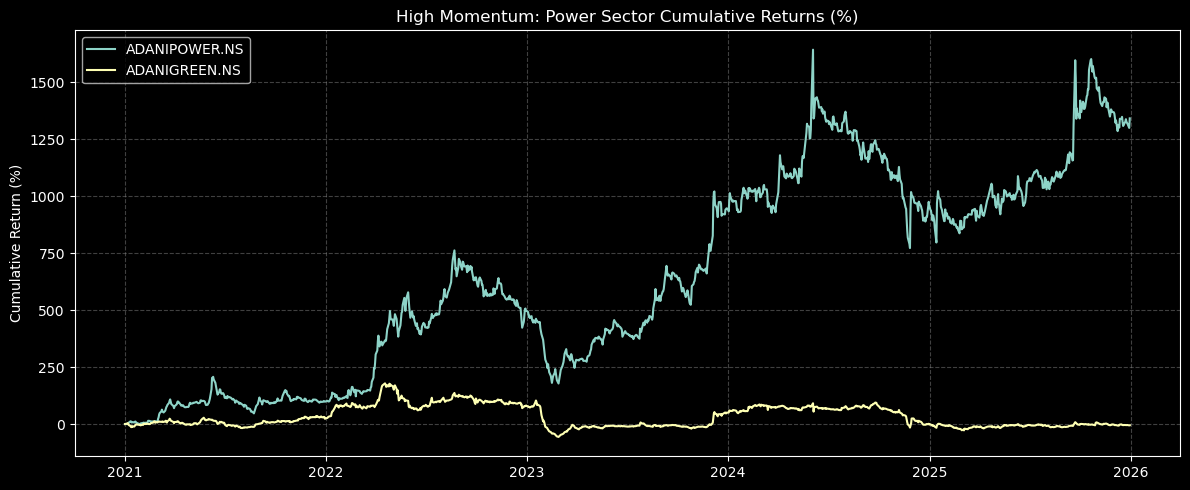

Plotting volatility for Telecom (IDEA.NS)...


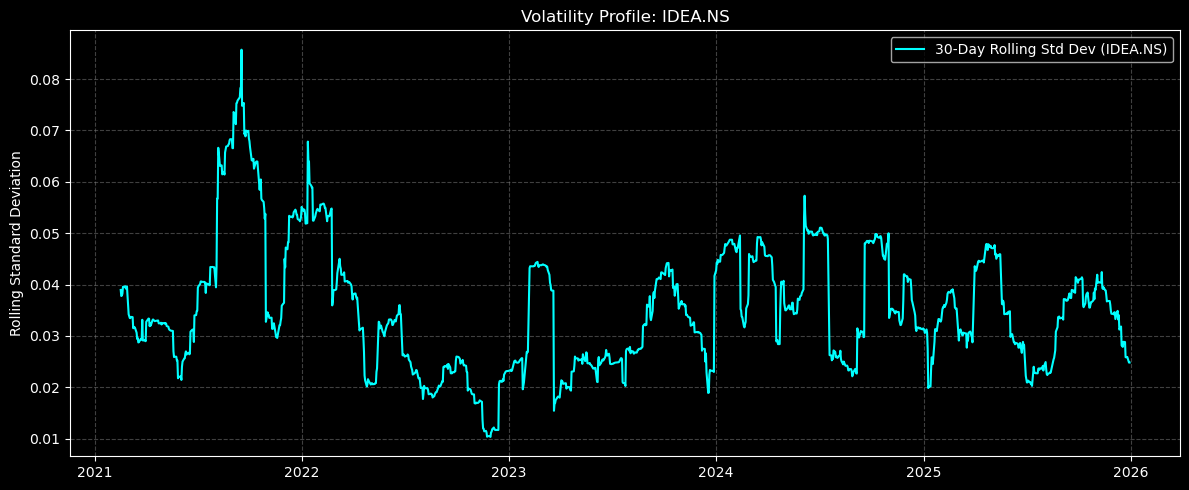

Plotting seasonal decomposition for Retail (NYKAA.NS)...


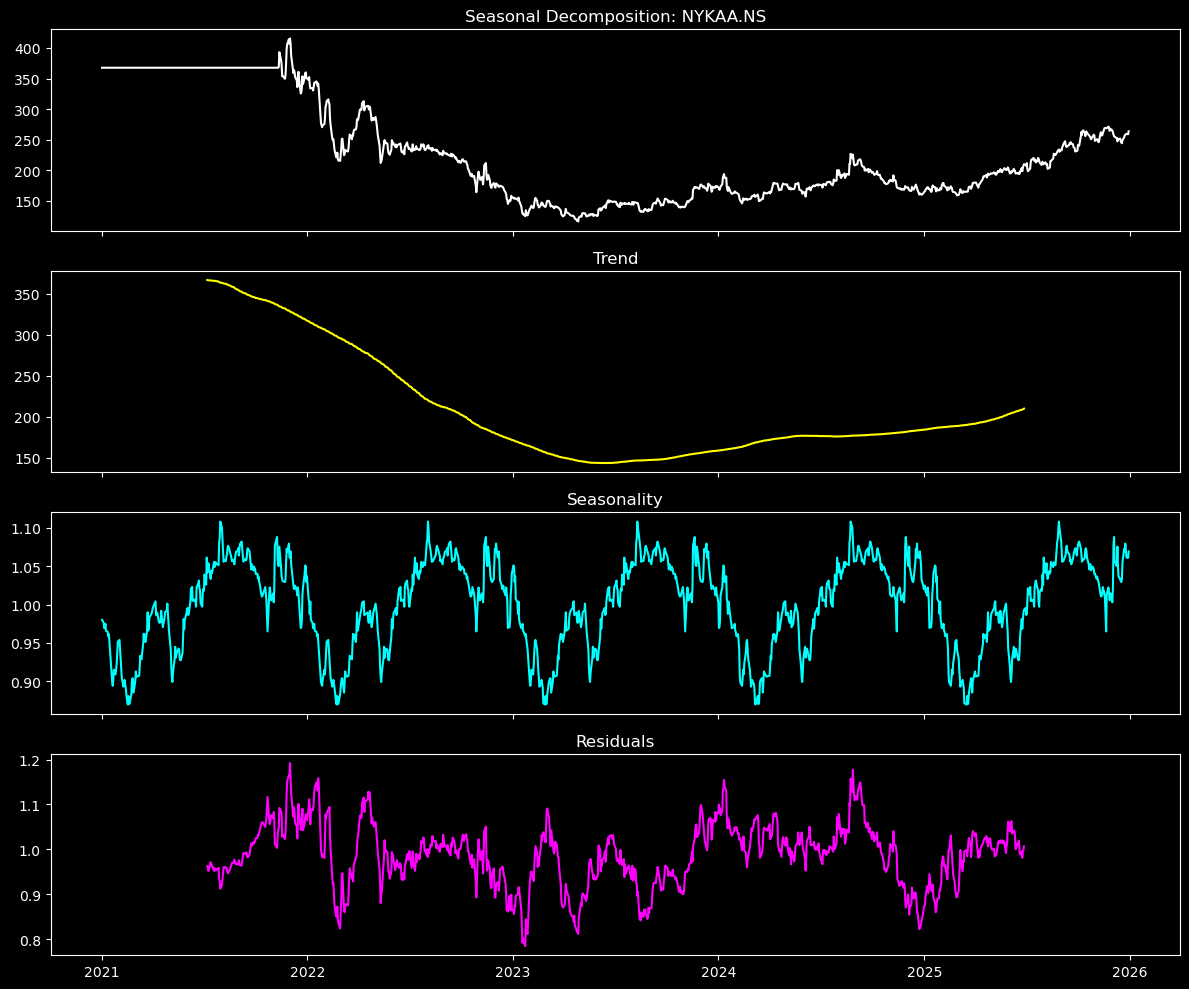


Task 1 done. Raw data saved to 'data/raw/capstone_raw_data.csv'.


In [2]:
# Task 1: Stock Selection and Data Fetching
# Author: Ayush Gahlot

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
import os
import warnings
warnings.filterwarnings('ignore')


# Dark mode for plots to look better in the report
plt.style.use('dark_background')

# Selecting stocks from 13 different sectors for good diversification
# Mixed large cap, mid cap, and small cap
stock_universe = {
    'Banking': ['SBIN.NS', 'J&KBANK.NS', 'BANKBARODA.NS'],
    'IT': ['POLICYBZR.NS', 'OFSS.NS'], 
    'Pharma': ['MANKIND.NS', 'NGLFINE.NS', 'SPARC.NS', 'NATCOPHARM.NS'],
    'FMCG': ['CARYSIL.NS', 'BAJAJCON.NS'],
    'Auto': ['BAJAJ-AUTO.NS', 'BHARATFORG.NS'],
    'Energy': ['ASIANENE.NS'],
    'Infra': ['LT.NS'],
    'Insurance': ['SBILIFE.NS', 'STARHEALTH.NS'],
    'Iron & Steel': ['GPIL.NS', 'JSWSTEEL.NS', 'TATASTEEL.NS'],
    'Logistics': ['ADANIPORTS.NS'],
    'Retailing': ['NYKAA.NS'],
    'Telecom': ['TATACOMM.NS', 'IDEA.NS'],
    'Power': ['ADANIPOWER.NS', 'ADANIGREEN.NS']
}

# Flatten dictionary to a single list
all_tickers = [ticker for sector in stock_universe.values() for ticker in sector]

# Fetch daily close prices till Dec 31 2025 as per the project rules
print(f"Fetching data for {len(all_tickers)} tickers...")

# Fetching one by one to prevent Yahoo Finance from blocking the IP 
# and throwing fake "delisted" errors.
data_frames = []

for ticker in all_tickers:
    print(f"Fetching {ticker}...")
    try:
        # Downloading individually
        df = yf.download(ticker, start="2021-01-01", end="2025-12-31", progress=False)['Close']
        
        # Squeeze dataframe to a series if yfinance returns a dataframe for a single ticker
        if isinstance(df, pd.DataFrame):
            df = df.squeeze()
            
        df.name = ticker
        data_frames.append(df)
    except Exception as e:
        print(f"Failed to fetch {ticker}: {e}")

# Combine all individual stock series into one massive DataFrame
data = pd.concat(data_frames, axis=1)

# Fill missing values caused by trading holidays
data = data.ffill().bfill()
print("\nData fetching complete.\n")


# --- Generating Data-Driven Justifications for the Report ---

# 1. Sector Momentum (Power Sector)
# Showing high momentum stocks to test how models handle steep trends
print("Plotting momentum for Power Sector...")
power_tickers = stock_universe['Power']
cumulative_returns = (data[power_tickers] / data[power_tickers].iloc[0]) - 1

plt.figure(figsize=(12, 5))
for ticker in power_tickers:
    plt.plot(cumulative_returns.index, cumulative_returns[ticker] * 100, label=ticker)
plt.title('High Momentum: Power Sector Cumulative Returns (%)')
plt.ylabel('Cumulative Return (%)')
plt.legend()
plt.grid(color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('../reports/figures/task1_momentum.png')
plt.show()

# 2. Volatility Profile (Vodafone Idea)
# Need volatile stocks to test the Volatility-Aware allocation strategy later
print("Plotting volatility for Telecom (IDEA.NS)...")
target_volatility_stock = 'IDEA.NS'
log_returns = np.log(data[target_volatility_stock] / data[target_volatility_stock].shift(1)).dropna()
rolling_std = log_returns.rolling(window=30).std()

plt.figure(figsize=(12, 5))
plt.plot(rolling_std.index, rolling_std, color='cyan', label=f'30-Day Rolling Std Dev ({target_volatility_stock})')
plt.title(f'Volatility Profile: {target_volatility_stock}')
plt.ylabel('Rolling Standard Deviation')
plt.legend()
plt.grid(color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('../reports/figures/task1_volatility.png')
plt.show()

# 3. Seasonal Decomposition (NYKAA)
# Checking for cyclical patterns in retail to test seasonality models
print("Plotting seasonal decomposition for Retail (NYKAA.NS)...")
target_seasonal_stock = 'NYKAA.NS'
decomposition = seasonal_decompose(data[target_seasonal_stock].dropna(), model='multiplicative', period=252)

fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
ax1.plot(data[target_seasonal_stock], color='white')
ax1.set_title(f'Seasonal Decomposition: {target_seasonal_stock}')
ax2.plot(decomposition.trend, color='yellow')
ax2.set_title('Trend')
ax3.plot(decomposition.seasonal, color='cyan')
ax3.set_title('Seasonality')
ax4.plot(decomposition.resid, color='magenta')
ax4.set_title('Residuals')

plt.tight_layout()
plt.savefig('../reports/figures/task1_seasonality.png')
plt.show()

# Save raw data to csv for the next tasks
data.to_csv('../data/raw/capstone_raw_data.csv')
print("\nTask 1 done. Raw data saved to 'data/raw/capstone_raw_data.csv'.")

In [3]:
# --- Generating the Master Justification Table for All Stocks (Fully Dynamic) ---
print("\nCalculating metrics for dynamic justification mapping...")

justification_mapping = []

for ticker in all_tickers:
    stock_data = data[ticker].dropna()
    
    # 1. Calculate Momentum (Total Return over the 5 years)
    total_return = (stock_data.iloc[-1] / stock_data.iloc[0]) - 1
    
    # 2. Calculate Volatility (Max 30-day Rolling Std Dev)
    log_returns = np.log(stock_data / stock_data.shift(1)).dropna()
    max_vol = log_returns.rolling(window=30).std().max()
    
    # 3. Dynamic Assignment Logic based on the math
    # If a stock more than doubled, it's a Momentum play
    if total_return > 1.0: 
        rationale = "Sector-Based Rationale (High Momentum)"
    # If it has wild swings in variance, it's a Volatility play
    elif max_vol > 0.035:  
        rationale = "Rolling Standard Deviation (Volatility Profile)"
    # Otherwise, it falls into stable baseline/seasonal trends
    else:
        rationale = "Seasonal Decomposition (Strong Cyclical Trends)"
        
    # Find which sector this ticker belongs to from our dictionary
    sector_name = [sec for sec, ticks in stock_universe.items() if ticker in ticks][0]
    
    justification_mapping.append({
        'Sector': sector_name,
        'Ticker': ticker,
        'Return': f"{total_return * 100:.1f}%",
        'Max Volatility': round(max_vol, 4),
        'Data-Driven Justification': rationale
    })

justification_df = pd.DataFrame(justification_mapping)

print("\n--- Task 1: Complete Stock Justification Table ---")
print(justification_df.to_string(index=False))

# Save the table for the final report
justification_df.to_csv('../reports/task1_complete_justifications.csv', index=False)


Calculating metrics for dynamic justification mapping...

--- Task 1: Complete Stock Justification Table ---
      Sector        Ticker  Return  Max Volatility                       Data-Driven Justification
     Banking       SBIN.NS  277.6%          0.0367          Sector-Based Rationale (High Momentum)
     Banking    J&KBANK.NS  326.7%          0.0560          Sector-Based Rationale (High Momentum)
     Banking BANKBARODA.NS  412.4%          0.0476          Sector-Based Rationale (High Momentum)
          IT  POLICYBZR.NS   54.6%          0.0533 Rolling Standard Deviation (Volatility Profile)
          IT       OFSS.NS  202.6%          0.0560          Sector-Based Rationale (High Momentum)
      Pharma    MANKIND.NS   51.4%          0.0309 Seasonal Decomposition (Strong Cyclical Trends)
      Pharma    NGLFINE.NS  -28.5%          0.0686 Rolling Standard Deviation (Volatility Profile)
      Pharma      SPARC.NS  -31.6%          0.0519 Rolling Standard Deviation (Volatility Profile)

In [4]:
import pandas as pd
import numpy as np

print("\nGenerating Task 4 Volatility & Trend Analysis Table...")

# FIX: Load the data directly from our saved CSV so we don't get a NameError
data = pd.read_csv('../data/raw/capstone_raw_data.csv', index_col=0, parse_dates=True)

task4_results = []

for stock in data.columns:
    series = data[stock].dropna()
    
    # 1. Volatility Estimation (Log Returns & 30-Day Rolling Std Dev)
    log_ret = np.log(series / series.shift(1)).dropna()
    current_vol = log_ret.rolling(window=30).std().iloc[-1] # Gets the exact volatility at Dec 31, 2025
    
    # 2. Trend Assessment (Comparing Short-Term vs Long-Term Baselines)
    sma_50 = series.rolling(window=50).mean().iloc[-1]
    sma_200 = series.rolling(window=200).mean().iloc[-1]
    
    if sma_50 > sma_200 * 1.05:
        trend = "Strong Upward"
    elif sma_50 < sma_200 * 0.95:
        trend = "Downward"
    else:
        trend = "Sideways / Consolidation"
        
    task4_results.append({
        'Stock': stock,
        'Dec 2025 Volatility (Risk)': round(current_vol, 4),
        'Overall Trend Status': trend
    })
    
task4_df = pd.DataFrame(task4_results)
task4_df.to_csv('../reports/task4_volatility_and_trend.csv', index=False)

print("Task 4 Table Saved. Here is a preview:")
print(task4_df.head(6).to_string(index=False))


Generating Task 4 Volatility & Trend Analysis Table...
Task 4 Table Saved. Here is a preview:
        Stock  Dec 2025 Volatility (Risk)     Overall Trend Status
      SBIN.NS                      0.0087            Strong Upward
   J&KBANK.NS                      0.0137 Sideways / Consolidation
BANKBARODA.NS                      0.0134            Strong Upward
 POLICYBZR.NS                      0.0201 Sideways / Consolidation
      OFSS.NS                      0.0120 Sideways / Consolidation
   MANKIND.NS                      0.0097                 Downward
